In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.special import lambertw

In [2]:
# Define the phase boundary model
def model(x, s, b, c, p):
    return s * x**(-b) * np.exp(c * x * np.exp(-p * x))

def model_short(x, s, b):
    return s * x**(-b) 

  
def panel_label_outside(ax, text, x=-0.28, y=1.12, fontsize=11, bold=False):
    ax.text(
        x, y, f"({text})" if len(text) == 1 else text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        clip_on=False
    )



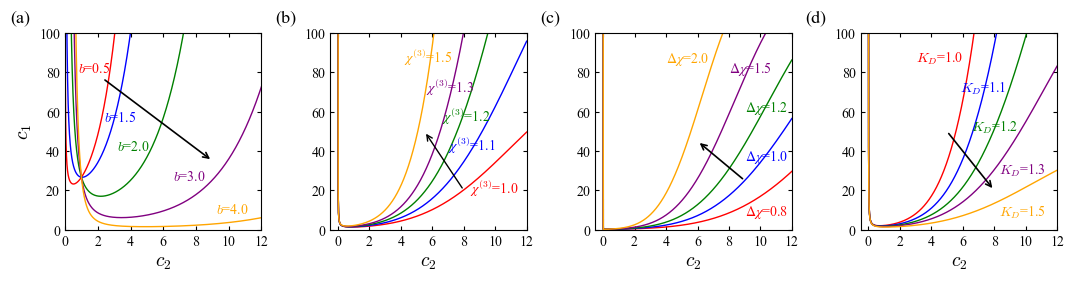

In [3]:
# Plot Figure 2
# Phase boundary geometry controlled by the physical parameters
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 14,
    "axes.titlesize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})


fig, axes = plt.subplots(1, 4, figsize=(12.8, 3.0) )

plt.subplots_adjust(wspace=0.35)

for ax in axes:
    ax.set_box_aspect(1) 
    ax.tick_params(which='both', top=True, right=True)
    
# Colors
colors = ['red', 'blue', 'green', 'purple', 'orange']


# -------------------------------------------------------------------------
# (a) Reentrant Phase Boundary vs phase separation parameter b
# -------------------------------------------------------------------------
x = np.linspace(1e-25, 12, 5000)
b_values = [0.5, 1.0, 2.0, 3.0, 4.0]
for i, (b, color) in enumerate(zip(b_values, colors)):
    #axes[0].plot(x, model_short(x, 15, b), color=color, lw=1)
    axes[0].plot(x, model(x, 10, b, 1, 0.02), color=color, lw=1)
axes[0].text(0.8, 80,  r'$b$=0.5',  color='red')
axes[0].text(2.4, 55, r'$b$=1.5', color='blue')
axes[0].text(3.2, 40, r'$b$=2.0', color='green')
axes[0].text(6.6, 25, r'$b$=3.0', color='purple')
axes[0].text(9.2, 8, r'$b$=4.0',  color='orange')
axes[0].annotate('',                     
        xy=(9, 35),              # arrow tip
        xytext=(2.3,77),          # arrow tail
        arrowprops=dict(
        arrowstyle='->',
        linewidth=1.2,
        color='black' )
)
axes[0].set_xlabel('$c_2$')
axes[0].set_ylabel('$c_1$')
axes[0].set_xlim(-0.005, 12)
axes[0].set_ylim(0, 100)
axes[0].set_xticks([0, 2, 4, 6, 8, 10, 12])
panel_label_outside(axes[0], "a", fontsize = 13)



# -------------------------------------------------------------------------
# (b) Reentrant Phase Boundary vs three-body repulsion χ^(3)
# -------------------------------------------------------------------------
x1 = np.linspace(1e-50, 1e-10, 10000)
x2 = np.linspace(1e-10, 12, 2000)
x = np.concatenate((x1, x2))

c_values = [1.0, 1.1, 1.2, 1.3, 1.5]
for c, color in zip(c_values, colors):
    axes[1].plot(x, model(x, 0.5, 0.8, c, 0.05), color=color, lw=1)  # three-body repulsion controls c
axes[1].text(8.4, 18.5,  r'$χ^{(3)}$=1.0',  color='red')
axes[1].text(7, 40, r'$χ^{(3)}$=1.1',  color='blue')
axes[1].text(6.6, 55, r'$χ^{(3)}$=1.2', color='green')
axes[1].text(5.6, 70, r'$χ^{(3)}$=1.3', color='purple')
axes[1].text(4.2, 85, r'$χ^{(3)}$=1.5', color='orange')
axes[1].annotate('',                     
        xy=(5.5, 50),              # arrow tip
        xytext=(8, 20),          # arrow tail
        arrowprops=dict(
        arrowstyle='->',
        linewidth=1.0,
        color='black' )
)
axes[1].set_xlabel('$c_2$')
axes[1].set_xlim(-0.5, 12)
axes[1].set_ylim(0, 100)
axes[1].set_xticks([0, 2, 4, 6, 8, 10, 12])
panel_label_outside(axes[1], "b", fontsize = 13)


# -------------------------------------------------------------------------
# Fig. 2(c) Reentrant Phase Boundary vs competition Δχ
# -------------------------------------------------------------------------


c_values = np.array([0.8, 1.0, 1.2, 1.5, 2.0])
p_values = 0.05 * c_values

for c, p, color in zip(c_values, p_values, colors):
    axes[2].plot(x, model(x, 0.1, 0.1, c, p), color=color, lw=1)   # competition enters both c and p
axes[2].text(9, 7, r'$Δχ$=0.8', color='red')
axes[2].text(9, 35, r'$Δχ$=1.0', color='blue')
axes[2].text(9, 60, r'$Δχ$=1.2', color='green')
axes[2].text(8, 80, r'$Δχ$=1.5', color='purple')
axes[2].text(4, 85, r'$Δχ$=2.0', color='orange')
axes[2].annotate('',                     
        xy=(6, 45),              # arrow tip
        xytext=(9, 25),          # arrow tail
        arrowprops=dict(
        arrowstyle='->',
        linewidth=1.2,
        color='black' )
)
axes[2].set_xlabel('$c_2$')
axes[2].set_xlim(-0.5, 12)
axes[2].set_ylim(0.0, 100)
axes[2].set_xticks([0, 2, 4, 6, 8, 10, 12])
panel_label_outside(axes[2], "c", fontsize = 13)


# -------------------------------------------------------------------------
# (d) Reentrant Phase Boundary vs Dissociaiton constant K_D 
# -------------------------------------------------------------------------

k_values = np.array([1.0, 1.1, 1.2, 1.3, 1.5])
c_values = 1.5 / k_values
for c, color in zip(c_values, colors):
    axes[3].plot(x, model(x, 0.5, 1.0, c, 0.05), color=color, lw=1)
axes[3].text(3, 85,  r'$K_D$=1.0',  color='red')
axes[3].text(5.8, 70, r'$K_D$=1.1',  color='blue')
axes[3].text(6.5, 50, r'$K_D$=1.2', color='green')
axes[3].text(8.3, 28, r'$K_D$=1.3', color='purple')
axes[3].text(8.3, 7, r'$K_D$=1.5', color='orange')
axes[3].annotate('',                     
        xy=(8, 20),              # arrow tip
        xytext=(5, 50),          # arrow tail
        arrowprops=dict(
        arrowstyle='->',
        linewidth=1.2,
        color='black' )
)
axes[3].set_xlabel('$c_2$')
axes[3].set_xlim(-0.5, 12)
axes[3].set_ylim(0, 100)
axes[3].set_xticks([0, 2, 4, 6, 8, 10, 12])
panel_label_outside(axes[3], "d", fontsize = 13)



# ==============================================================
# Export
# ==============================================================
#fig.savefig("Figure_3_plot.pdf", bbox_inches="tight")
#fig.savefig("Figure_3_plot.png", dpi=600)

plt.show()